# Bosonic Causal Projection: P / W

This notebook runs the same graph-based check as `plot_causal_boson_pw.py` in a Jupyter-friendly, top-to-bottom order. It builds a single-band Hubbard fixture, computes `P` and `W`, adds controlled low-frequency noise on the uniform bosonic Matsubara grid, and compares QAssemble's bosonic causal projection against the external `causal_boson.py` reference.

In [1]:
%matplotlib inline

from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path | None = None) -> Path:
    """Find the repository root from the current Jupyter working directory."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "QAssemble").exists():
            return candidate
    raise RuntimeError(
        "Could not find the DiagE repository root. Start Jupyter from the repo "
        "or a subdirectory that contains pyproject.toml in its parents."
    )


PROJECT_ROOT = find_repo_root()
TEST_DIR = PROJECT_ROOT / "src" / "QAssemble" / "utility" / "test"
SRC_DIR = PROJECT_ROOT / "src"

for path in (str(SRC_DIR), str(TEST_DIR)):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"TEST_DIR     = {TEST_DIR}")

PROJECT_ROOT = /Users/moseongjun/usr/DiagE
TEST_DIR     = /Users/moseongjun/usr/DiagE/src/QAssemble/utility/test


In [2]:
from plot_causal_boson_pw import (
    REFERENCE_CAUSAL_BOSON,
    add_low_frequency_noise,
    boson_lat_dlr_to_uniform,
    load_reference_causal_boson,
    plot_channel,
    print_difference,
    qassemble_scalar_projection,
    reference_causal_projection,
    single_band_hubbard,
    single_band_vbare,
)
from QAssemble.BLatDyn import P, W
from QAssemble.FLatDyn import G0

plt.rcParams["figure.dpi"] = 120

## Configuration

Edit these values and re-run the cells below. `P_COEFFICIENT_SIGN` and `W_COEFFICIENT_SIGN` use the QP convention from `CausalProjection`: `-1` enforces non-positive pole coefficients and `+1` enforces non-negative pole coefficients.

In [3]:
REFERENCE_PATH = REFERENCE_CAUSAL_BOSON
SAVE_DIR: Path | None = None
NOISE = 1.0e-4
CONSTRAINT_TOL = 1.0e-7
P_COEFFICIENT_SIGN = -1
W_COEFFICIENT_SIGN = -1
REFLECTION_SYMMETRY = True

if not REFERENCE_PATH.exists():
    raise FileNotFoundError(
        f"Reference causal_boson.py was not found: {REFERENCE_PATH}. "
        "Set REFERENCE_PATH to the local reference script before continuing."
    )

print(f"REFERENCE_PATH = {REFERENCE_PATH}")

REFERENCE_PATH = /Users/moseongjun/usr/FullGWEDMFT/bin/causal_boson.py


## Build P and W

In [4]:
causal_boson = load_reference_causal_boson(REFERENCE_PATH)
crystal, dlr, hamtb = single_band_hubbard()

g0 = G0(crystal=crystal, dlr=dlr, hamtb=hamtb, hdf5file=None)
p = P(crystal=crystal, dlr=dlr, green=g0.rt, hdf5file=None)
vbare = single_band_vbare(crystal)
w = W(crystal=crystal, dlr=dlr, pol=p.kf, vbare=vbare, hdf5file=None)

print(f"nk={crystal.nk}, len(dlr.nu)={len(dlr.nu)}, len(uniform nu)={len(dlr.MatsubaraBosonUniform())}")

nk=8, len(dlr.nu)=47, len(uniform nu)=387


## Prepare Uniform-Grid Inputs

In [5]:
nu_uniform = dlr.MatsubaraBosonUniform()

p_uniform = boson_lat_dlr_to_uniform(dlr, p.kf)
p_noisy = add_low_frequency_noise(
    p_uniform,
    nu_uniform,
    cutoff=dlr.cutoff,
    norm=NOISE,
    seed=11,
)

wc_uniform = boson_lat_dlr_to_uniform(dlr, w.ckf)
w_uniform = wc_uniform + w.vbare.k[..., np.newaxis]
w_noisy = add_low_frequency_noise(
    w_uniform,
    nu_uniform,
    cutoff=dlr.cutoff,
    norm=NOISE,
    seed=17,
)

print("p_uniform shape:", p_uniform.shape)
print("w_uniform shape:", w_uniform.shape)

p_uniform shape: (1, 1, 1, 1, 8, 387)
w_uniform shape: (1, 1, 1, 1, 8, 387)


## Tail Diagnostics

These values are useful when deciding whether a requested coefficient sign is compatible with the fitted high-frequency moment. For reflected bosons, non-negative coefficients require `-c2 >= 0` up to tolerance.

In [6]:
p_moment, p_high = p.Moment(p_noisy, grid="uniform")
w_moment, w_high = w.Moment(w_noisy, grid="uniform")

print("P channel k=0")
print("  c0  =", p_high[0, 0, 0, 0, 0].real)
print("  c2  =", p_moment[0, 0, 0, 0, 0, 1].real)
print("  -c2 =", -p_moment[0, 0, 0, 0, 0, 1].real)

print("W channel k=0")
print("  c0  =", w_high[0, 0, 0, 0, 0].real)
print("  c2  =", w_moment[0, 0, 0, 0, 0, 1].real)
print("  -c2 =", -w_moment[0, 0, 0, 0, 0, 1].real)

P channel k=0
  c0  = -1.3142737658995847e-14
  c2  = -7.190318787804443e-11
  -c2 = 7.190318787804443e-11
W channel k=0
  c0  = 1.5999999999999932
  c2  = 2.198554972455296e-10
  -c2 = -2.198554972455296e-10


## Run Causal Projections

In [7]:
p_qassemble = qassemble_scalar_projection(
    p,
    p_noisy,
    coefficient_sign=P_COEFFICIENT_SIGN,
    reflection_symmetry=REFLECTION_SYMMETRY,
    constraint_tol=CONSTRAINT_TOL,
)
p_reference = reference_causal_projection(
    p,
    p_noisy,
    causal_boson,
    coefficient_sign=P_COEFFICIENT_SIGN,
    reflection_symmetry=REFLECTION_SYMMETRY,
    constraint_tol=CONSTRAINT_TOL,
)
print_difference("P", p_qassemble, p_reference)

P: max|QAssemble-reference|=0.000e+00, rel=0.000e+00


In [8]:
w_qassemble = qassemble_scalar_projection(
    w,
    w_noisy,
    coefficient_sign=W_COEFFICIENT_SIGN,
    reflection_symmetry=REFLECTION_SYMMETRY,
    constraint_tol=CONSTRAINT_TOL,
)
w_reference = reference_causal_projection(
    w,
    w_noisy,
    causal_boson,
    coefficient_sign=W_COEFFICIENT_SIGN,
    reflection_symmetry=REFLECTION_SYMMETRY,
    constraint_tol=CONSTRAINT_TOL,
)
print_difference("W", w_qassemble, w_reference)

W: max|QAssemble-reference|=6.384e-14, rel=8.449e-15


## Plot Representative Channels

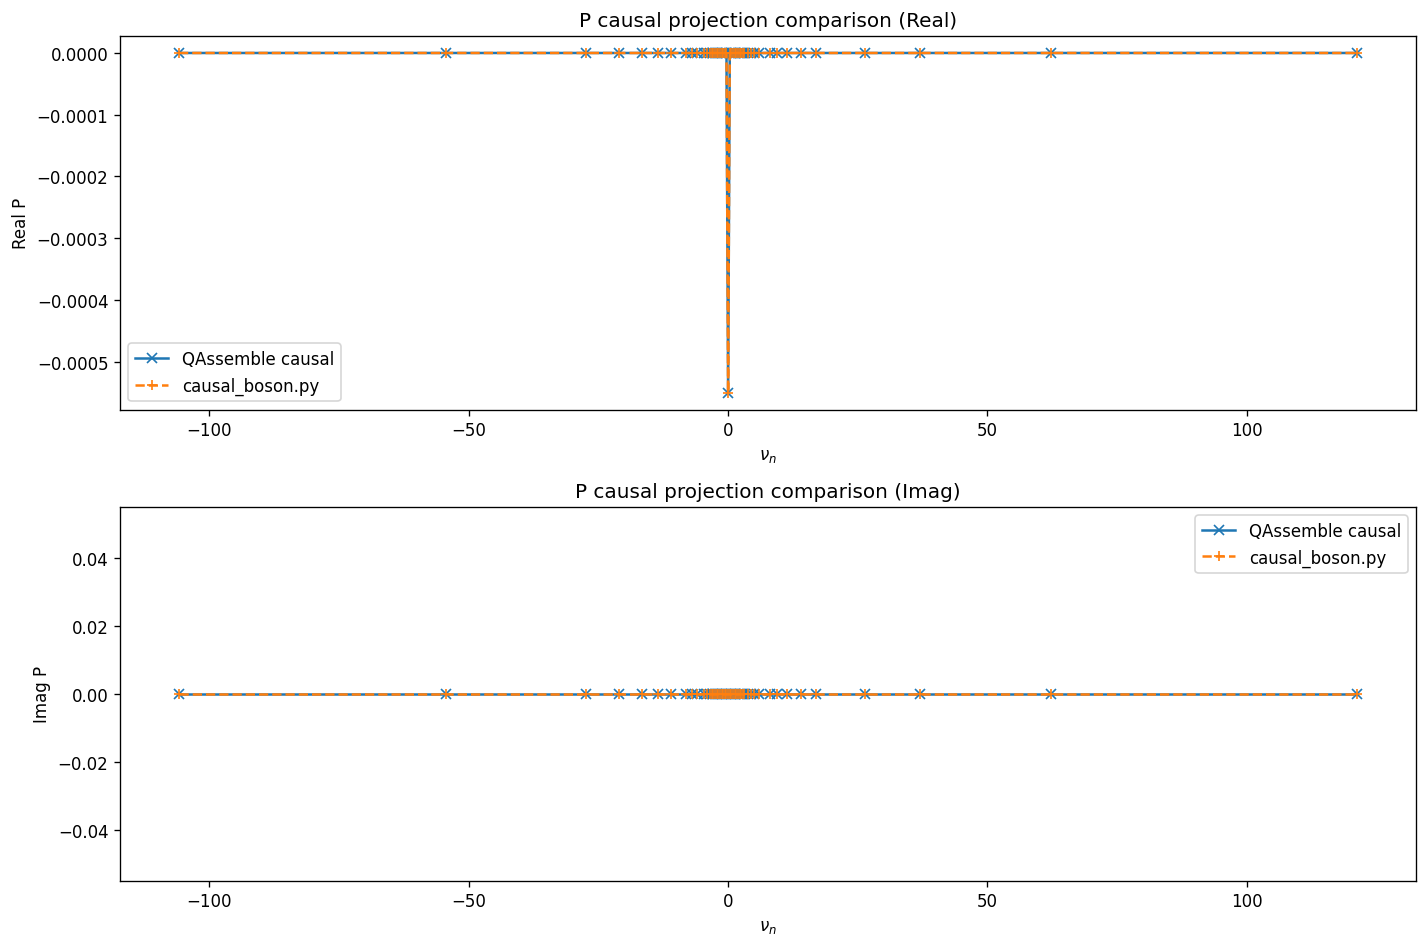

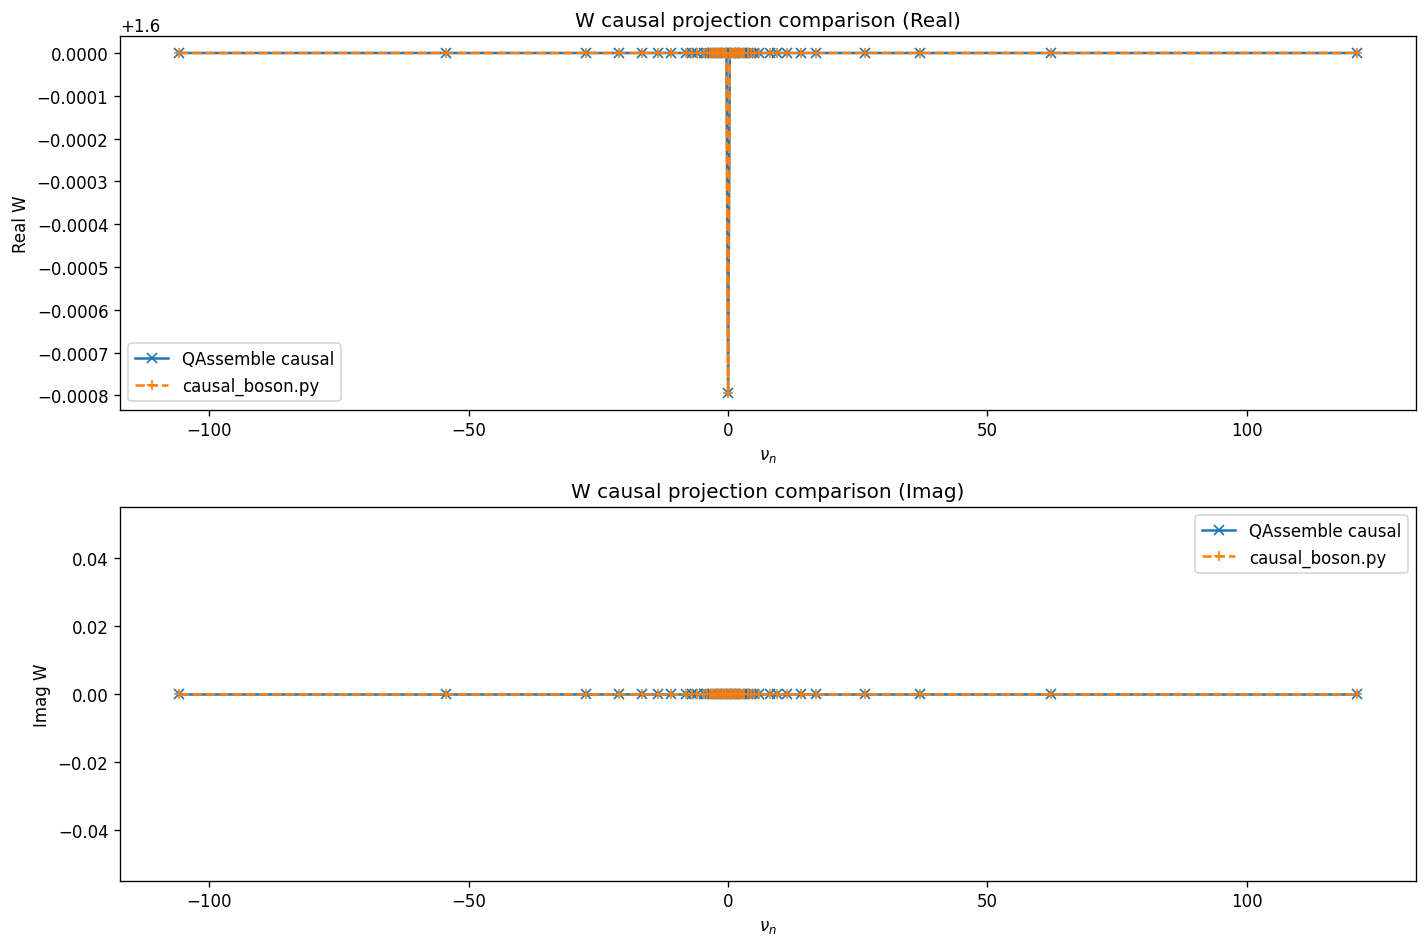

In [9]:
plot_channel(
    "P",
    dlr,
    p.kf[0, 0, 0, 0, 0, :],
    p_noisy[0, 0, 0, 0, 0, :],
    p_qassemble[0, 0, 0, 0, 0, :],
    p_reference[0, 0, 0, 0, 0, :],
    save_dir=SAVE_DIR,
)
plot_channel(
    "W",
    dlr,
    w.kf[0, 0, 0, 0, 0, :],
    w_noisy[0, 0, 0, 0, 0, :],
    w_qassemble[0, 0, 0, 0, 0, :],
    w_reference[0, 0, 0, 0, 0, :],
    save_dir=SAVE_DIR,
)
plt.show()